In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import ast

In [2]:
h1 = 1
m = 0.5
def coupling(matrix_1, matrix_2):
    s11_1, s12_1 = matrix_1[0, 0], matrix_1[0, 1]
    s21_1, s22_1 = matrix_1[1, 0], matrix_1[1, 1]
    s11_2, s12_2 = matrix_2[0, 0], matrix_2[0, 1]
    s21_2, s22_2 = matrix_2[1, 0], matrix_2[1, 1]
    
    denom = 1 - s11_2 * s22_1
    s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
    s12 = s12_1 * s12_2 / denom
    s21 = s21_2 * s21_1 / denom
    s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom
    
    return np.array([[s11, s12], [s21, s22]], dtype=np.complex128)

def multiple_coupling(matrix_collect):
    result = matrix_collect[0]
    for matrix in matrix_collect[1:]:
        result = coupling(result, matrix)
    return result

def coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a):
    constant_1 = 2 * m * (y1 + 1j * y2) / (h1**2)
    constant_2 = 2 * m * (y1 - 1j * y2) / (h1**2)
    
    di = np.array([constant_1 if i % 2 == 0 or i >= 2 * N and i < 2 * N + n3 else constant_2 
                   for i in range(2 * N + n3 + n4)], dtype=complex)
    
    x_0 = 0
    x_1 = a * (2 * N + n3 + n4) - a + x_0
    location = np.linspace(x_0, x_1, 2 * N + n3 + n4)
 #   print(location)
    k = np.sqrt(E * 2 * m) / h1
    exp_2jk = np.exp(2j * k * location)
    exp_minus_2jk = np.exp(-2j * k * location)
    
    matrix_collect = np.zeros((2 * N + n3 + n4, 2, 2), dtype=complex)
    for i in range(2 * N + n3 + n4):
        s11 = di[i] * exp_2jk[i]
        s12 = 2j * k
        s21 = 2j * k
        s22 = di[i] * exp_minus_2jk[i]
        
        matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
  #  print(matrix_collect)
    return multiple_coupling(matrix_collect)

def Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[1, 0])**2)

def Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[0, 0])**2)

In [3]:
N = 100
n3 = 0
n4 = 0
y1 = 2
y2 = -2
a = 0.5  
E_set = np.linspace(0.001,20,100)
T_set = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_set]
R_set = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_set]
Sum_set = [T + R for T,R in zip(T_set,R_set)]

In [30]:
# 创建DataFrame保存数据
data = {
    'E_set': E_set,
    'T_set': T_set,
    'R_set': R_set,
    'Sum_values': Sum_values
}
df = pd.DataFrame(data)

# 创建保存路径
save_dir = r"C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果"
os.makedirs(save_dir, exist_ok=True)

# 按参数命名文件
filename = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_a{a}_E_change.xlsx"
save_path = os.path.join(save_dir, filename)

# 保存到Excel
df.to_excel(save_path, index=False)
print(f"数据已保存至: {save_path}")

NameError: name 'Sum_values' is not defined

In [5]:
data = {
    'E_set' : E_set,
    'T_set' : T_set,
    'R_set' : R_set,
    'Sum_set': Sum_set
}
df = pd.DataFrame(data)


In [21]:
save = rf"C:\Users\taoji\Desktop\草稿纸\25.5.3\a{a}"
os.makedirs(save,exist_ok=True)

In [19]:
name=f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_a{a}_E_change.xlsx"
save_path = os.path.join(save,name)

In [36]:
df.to_excel(save_path,index=False)

In [37]:
print(f"数据已保存至: {save_path}")

数据已保存至: C:\Users\taoji\Desktop\草稿纸\25.5.3\a0.5\N100_n30_n40_y12_y2-2_a0.5_E_change.xlsx


In [38]:
# 读取 Excel 文件
N = 100
n3 = 0
n4 = 0
y1 = 2
y2 = -2
a = 0.5  
save=rf'C:\Users\taoji\Desktop\草稿纸\25.5.3\a0.5'
file_name = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_a{a}_E_change.xlsx"
save_path = os. path.join(save, file_name)
loaded_df = pd.read_excel(save_path)


In [39]:
print(loaded_df)

       E_set          T_set     R_set   Sum_set
0    0.00100  2.326007e-182  0.984312  0.984312
1    0.20301  7.113218e-176  0.795968  0.795968
2    0.40502  2.686829e-171  0.721388  0.721388
3    0.60703  9.749770e-167  0.666822  0.666822
4    0.80904  4.103179e-162  0.622293  0.622293
..       ...            ...       ...       ...
95  19.19196   1.114633e+00  0.193862  1.308495
96  19.39397   1.231355e+00  0.408369  1.639724
97  19.59598   1.029766e+00  0.054887  1.084653
98  19.79799   1.048826e+00  0.094143  1.142969
99  20.00000   1.185333e+00  0.374055  1.559388

[100 rows x 4 columns]


In [42]:
print(loaded_df.dtypes)

E_set      float64
T_set      float64
R_set      float64
Sum_set    float64
dtype: object


In [49]:
E_set = loaded_df["E_set"]
T_set = loaded_df["T_set"]
R_set = loaded_df["R_set"]
Sum_set = loaded_df["Sum_set"]

In [50]:
print(E_set)

0      0.00100
1      0.20301
2      0.40502
3      0.60703
4      0.80904
        ...   
95    19.19196
96    19.39397
97    19.59598
98    19.79799
99    20.00000
Name: E_set, Length: 100, dtype: float64


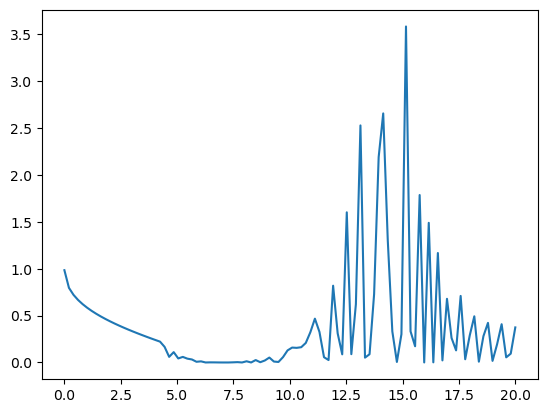

In [52]:
plt.plot(E_set, R_set)  
plt.show()

In [41]:
# 将字符串形式的列表转换为实际的列表
def safe_literal_eval(x):
    if isinstance(x, str):  # 如果是字符串才尝试解析
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return x
    else:  # 已经是数字或列表就直接返回
        return x
E_set = loaded_df["E_set"].apply(safe_literal_eval)
T_set = loaded_df["T_set"].apply(safe_literal_eval)
R_set = loaded_df["R_set"].apply(safe_literal_eval)
Sum_set = loaded_df["Sum_set"].apply(safe_literal_eval)

In [60]:
# 读取 Excel 文件
N = 100
n3 = 0
n4 = 0
y1 = 2
y2 = -2
a = 0.5  
file_name = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_a{a}_E_change.xlsx"
save_dir=rf'C:\Users\taoji\Desktop\草稿纸\25.5.3\a0.5'

save_path=os.path.join(save_dir,file_name)
loaded_df=pd.read_excel(save_path)


# 将字符串形式的列表转换为实际的列表
def safe_literal_eval(x):
    if isinstance(x, str):  # 如果是字符串才尝试解析
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return x
    else:  # 已经是数字或列表就直接返回
        return x

E_set = loaded_df["E_set"].apply(safe_literal_eval)
T_set = loaded_df["T_set"].apply(safe_literal_eval)
R_set = loaded_df["R_set"].apply(safe_literal_eval)
Sum_set = loaded_df["Sum_set"].apply(safe_literal_eval)



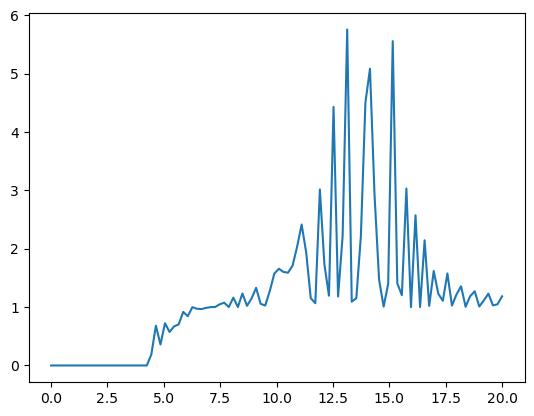

In [61]:
plt.plot(E_set,T_set)

In [64]:
 # 这会调整数组大小  
import numpy as np 
 
a = np.array([[1,2,3],[4,5,6]]) 
a.shape =  (3,2)  
print (a)

[[1 2]
 [3 4]
 [5 6]]
